In [1]:
# 1) 한 번만: 압축 풀기
!tar xzf sample_data/EnglishFnt.tgz -C sample_data/

In [2]:
# ────────────────────────────────────────────────────────────────
# 0) EnglishFnt에서 D/N/E 데이터셋 자동 구축
# ────────────────────────────────────────────────────────────────
import os
from pathlib import Path
from PIL import Image
import shutil
import random

# 원본 폰트 이미지 경로
FNT_BASE = Path("sample_data/English/Fnt")
OUT_BASE = Path("dataset")
CLASS_MAP = {'Sample014': 'D', 'Sample024': 'N', 'Sample015': 'E'}

# dataset/D, dataset/N, dataset/E 폴더 생성 및 초기화
for c in ['D', 'N', 'E']:
    d = OUT_BASE / c
    if d.exists():
        shutil.rmtree(d)
    d.mkdir(parents=True, exist_ok=True)

# 클래스별로 파일 복사 (최대 2000장씩 샘플)
for sample, label in CLASS_MAP.items():
    src = FNT_BASE / sample
    dst = OUT_BASE / label
    files = list(src.glob("*.png"))
    random.shuffle(files)
    for i, f in enumerate(files[:2000]):
        img = Image.open(f).convert("L").resize((32,32))
        img.save(dst / f"{label}_{i:04d}.png")

print("EnglishFnt → dataset/D,N,E 자동 구축 완료")

# ────────────────────────────────────────────────────────────────
# 1) Keras 데이터셋 로드 및 증강
# ────────────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE    = (32, 32)
BATCH_SIZE  = 64
EPOCHS      = 30
TFLITE_PATH = "dne_classifier.tflite"
CLASS_NAMES = ["D", "N", "E"]
VALID_SPLIT = 0.2
SEED        = 42

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset",
    labels="inferred",
    label_mode="categorical",
    class_names=CLASS_NAMES,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=VALID_SPLIT,
    subset="training",
    seed=SEED
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset",
    labels="inferred",
    label_mode="categorical",
    class_names=CLASS_NAMES,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=VALID_SPLIT,
    subset="validation",
    seed=SEED
)

normalization = layers.Rescaling(1.0 / 255)
data_augmentation = tf.keras.Sequential([
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.3),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomFlip("horizontal"),
])


def preprocess_train(x, y):
    x = tf.expand_dims(x, -1) if x.shape[-1] != 1 else x
    x = data_augmentation(x)
    x = normalization(x)
    return x, y

train_ds = train_ds.map(preprocess_train).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (normalization(x), y)).prefetch(buffer_size=tf.data.AUTOTUNE)

# ────────────────────────────────────────────────────────────────
# 2) CNN 모델 정의 및 학습
# ────────────────────────────────────────────────────────────────
def build_dne_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(32, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(64, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.3),

        layers.Conv2D(128, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

model = build_dne_model(IMG_SIZE + (1,), len(CLASS_NAMES))
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# ────────────────────────────────────────────────────────────────
# 3) TFLite 변환 및 저장
# ────────────────────────────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)
print(f"3-class TFLite model saved at '{TFLITE_PATH}'")

EnglishFnt → dataset/D,N,E 자동 구축 완료
Found 3048 files belonging to 3 classes.
Using 2439 files for training.
Found 3048 files belonging to 3 classes.
Using 609 files for validation.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             

 Total params: 157,027 (613.39 KB)

 Trainable params: 156,387 (610.89 KB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 17s 183ms/step - accuracy: 0.4469 - loss: 1.0539 - val_accuracy: 0.3383 - val_loss: 1.1641
Epoch 2/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6811 - loss: 0.7634 - val_accuracy: 0.4992 - val_loss: 1.3112
Epoch 3/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8184 - loss: 0.5106 - val_accuracy: 0.3448 - val_loss: 1.3069
Epoch 4/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8727 - loss: 0.3696 - val_accuracy: 0.3580 - val_loss: 0.9878
Epoch 5/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8802 - loss: 0.3282 - val_accuracy: 0.9031 - val_loss: 0.8140
Epoch 6/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9099 - loss: 0.2387 - val_accuracy: 0.8555 - val_loss: 0.7645
Epoch 7/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9130 - loss: 0.2508 - val_accuracy: 0.6174 - val_loss: 0.8249
Epoch 8/30
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9140 - loss: 0.2358 - val_accuracy: 0.6913 -

In [3]:
!unzip /content/row_images.zip -d table_cell/

Archive:  /content/row_images.zip
   creating: table_cell/row_images/
   creating: table_cell/row_images/images/
  inflating: table_cell/row_images/images/base_001.png  
  inflating: table_cell/row_images/images/base_002.png  
  inflating: table_cell/row_images/images/base_003.png  
  inflating: table_cell/row_images/images/base_004.png  
  inflating: table_cell/row_images/images/base_005.png  
  inflating: table_cell/row_images/images/base_006.png  
  inflating: table_cell/row_images/images/base_007.png  
  inflating: table_cell/row_images/images/base_008.png  
  inflating: table_cell/row_images/images/base_009.png  
  inflating: table_cell/row_images/images/base_010.png  
  inflating: table_cell/row_images/images/base_011.png  
  inflating: table_cell/row_images/images/base_012.png  
  inflating: table_cell/row_images/images/base_013.png  
  inflating: table_cell/row_images/images/base_014.png  
  inflating: table_cell/row_images/images/base_015.png  
  inflating: table_cell/row_imag

In [4]:
import os, random, shutil

# row_images.zip을 table_cell 안에 풀어서 생긴 경로
root = "/content/table_cell/row_images"

# 실제 폴더명
img_dir = os.path.join(root, "images")
label_dir = os.path.join(root, "labels")

# train/val 폴더 생성
train_img = os.path.join(root, "images/train")
val_img   = os.path.join(root, "images/val")
train_lab = os.path.join(root, "labels/train")
val_lab   = os.path.join(root, "labels/val")

os.makedirs(train_img, exist_ok=True)
os.makedirs(val_img, exist_ok=True)
os.makedirs(train_lab, exist_ok=True)
os.makedirs(val_lab, exist_ok=True)

# 이미지 목록 불러오기
images = [f for f in os.listdir(img_dir) if f.lower().endswith((".jpg", ".png"))]
random.shuffle(images)

# 80%/20% split
split_idx = int(len(images) * 0.8)
train_list = images[:split_idx]
val_list   = images[split_idx:]

def move_pair(img_name, dst_img_dir, dst_lab_dir):
    base, _ = os.path.splitext(img_name)
    shutil.copy2(os.path.join(img_dir, img_name), dst_img_dir)
    shutil.copy2(os.path.join(label_dir, base + ".txt"), dst_lab_dir)

for im in train_list:
    move_pair(im, train_img, train_lab)

for im in val_list:
    move_pair(im, val_img, val_lab)

print(len(train_list), "train,", len(val_list), "val")


440 train, 110 val


In [5]:
%%writefile /content/table_cell/row_images/data.yaml
path: /content/table_cell/row_images

train: images/train
val: images/val

nc: 1
names: ['cell']


Writing /content/table_cell/row_images/data.yaml


In [6]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 33.0 MB/s eta 0:00:00


In [7]:
from ultralytics import YOLO

# 작은 프리트레인 모델 가져오기
model = YOLO("yolov8n.pt")   # 너무 느리면 n / 더 정확히 하고 싶으면 s, m 로 바꿔도 됨

model.train(
    data="/content/table_cell/row_images/data.yaml",
    epochs=80,        # 50~100 사이 아무거나, 데이터 적으니까 너무 크게만 안 가면 됨
    imgsz=640,
    batch=8,
    patience=20,      # 개선 없으면 자동 조기 종료
    project="runs_table",
    name="cell_detector"
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.230 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/table_cell/row_images/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d39e0322cf0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [8]:
from ultralytics import YOLO

best = YOLO("runs_table/cell_detector/weights/best.pt")

best.predict(
    source="/content/table_cell/row_images/images/val",
    conf=0.3,
    save=True
)



image 1/110 /content/table_cell/row_images/images/val/base_004.png: 96x640 124 cells, 41.9ms
image 2/110 /content/table_cell/row_images/images/val/base_008.png: 96x640 124 cells, 6.2ms
image 3/110 /content/table_cell/row_images/images/val/base_027.png: 96x640 124 cells, 6.0ms
image 4/110 /content/table_cell/row_images/images/val/base_034.png: 96x640 124 cells, 6.1ms
image 5/110 /content/table_cell/row_images/images/val/base_035.png: 96x640 124 cells, 6.0ms
image 6/110 /content/table_cell/row_images/images/val/base_041.png: 96x640 124 cells, 6.8ms
image 7/110 /content/table_cell/row_images/images/val/base_043.png: 96x640 124 cells, 5.8ms
image 8/110 /content/table_cell/row_images/images/val/base_045.png: 96x640 124 cells, 7.1ms
image 9/110 /content/table_cell/row_images/images/val/base_047.png: 96x640 124 cells, 6.0ms
image 10/110 /content/table_cell/row_images/images/val/font_001.png: 96x640 124 cells, 5.9ms
image 11/110 /content/table_cell/row_images/images/val/font_013.png: 96x640 1

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'cell'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 

TFLite input shape: (np.int32(32), np.int32(32), np.int32(1))


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


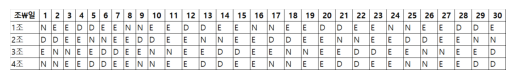


image 1/1 /content/test_1.png: 96x640 126 cells, 9.2ms
Speed: 0.8ms preprocess, 9.2ms inference, 1.3ms postprocess per image at shape (1, 3, 96, 640)

=== 1조 결과 ===
1조 01일: N (98.6%)
1조 02일: N (87.1%)
1조 03일: - (blank)
1조 04일: N (100.0%)
1조 05일: N (53.0%)
1조 06일: N (64.5%)
1조 07일: D (98.2%)
1조 08일: D (99.3%)
1조 09일: N (56.4%)
1조 10일: E (61.1%)
1조 11일: N (100.0%)
1조 12일: N (100.0%)
1조 13일: E (67.8%)
1조 14일: N (90.2%)
1조 15일: D (99.1%)
1조 16일: D (99.1%)
1조 17일: E (62.6%)
1조 18일: N (99.8%)
1조 19일: N (100.0%)
1조 20일: N (100.0%)
1조 21일: N (67.8%)
1조 22일: N (99.6%)
1조 23일: D (99.4%)
1조 24일: D (97.9%)
1조 25일: E (51.0%)
1조 26일: N (93.1%)
1조 27일: N (100.0%)
1조 28일: N (100.0%)
1조 29일: E (68.0%)
1조 30일: N (93.6%)
1조 31일: D (97.8%)
1조 32일: D (97.9%)
1조 33일: E (61.2%)

=== 2조 결과 ===
2조 01일: N (98.8%)
2조 02일: D (92.7%)
2조 03일: D (99.3%)
2조 04일: N (99.0%)
2조 05일: E (51.0%)
2조 06일: N (100.0%)
2조 07일: N (100.0%)
2조 08일: N (99.8%)
2조 09일: D (97.8%)
2조 10일: D (97.6%)
2조 11일: N (99.6%)
2조 12일: N (94.7%)


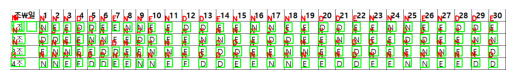

In [9]:
import cv2
import numpy as np
from ultralytics import YOLO
import tensorflow as tf
import os
import matplotlib.pyplot as plt

####################################
# 1) YOLO 모델 로드
####################################

yolo_model = YOLO("runs_table/cell_detector/weights/best.pt")


####################################
# 2) TFLite D/N/E 분류기 로드
####################################

tflite_path = "/content/dne_classifier.tflite"

if not os.path.exists(tflite_path):
    raise FileNotFoundError(f"TFLite 모델을 찾을 수 없음: {tflite_path}")

interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

INPUT_H = input_details[0]['shape'][1]
INPUT_W = input_details[0]['shape'][2]
INPUT_C = input_details[0]['shape'][3]

print("TFLite input shape:", (INPUT_H, INPUT_W, INPUT_C))

# TFLite 모델이 내보내는 클래스 순서에 맞게
CLASS_NAMES = ['D', 'N', 'E']


####################################
# 3) 빈칸 판단 함수
####################################

def is_blank_cell(crop, dark_thresh=230, min_dark_ratio=0.005):
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    dark_ratio = np.mean(gray < dark_thresh)
    return dark_ratio < min_dark_ratio


####################################
# 4) TFLite로 D/N/E 예측 (라벨 + 확률 반환)
####################################

def predict_dne_tflite(crop_resized):
    """
    crop_resized: (H, W, C) float32 / 0~1
    return: (label, prob)  e.g. ('D', 0.9123)
    """
    x = np.expand_dims(crop_resized, axis=0)

    interpreter.set_tensor(input_details[0]['index'], x)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])  # (1, num_classes)

    probs = output[0]
    pred_idx = int(np.argmax(probs))
    pred_label = CLASS_NAMES[pred_idx]
    pred_prob = float(probs[pred_idx])

    return pred_label, pred_prob


####################################
# 5) 한 줄(row) 이미지 전체 처리
####################################

def classify_row_cells(image_path, conf=0.3):
    """
    image_path: 한 줄짜리 row 이미지 경로
    return:
        labels_with_prob: [('-', None), ('D', 0.91), ...]
        boxes           : [(x1,y1,x2,y2), ...]
    """
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"이미지를 열 수 없음: {image_path}")

    # YOLO 추론
    result = yolo_model(image_path, conf=conf)[0]

    if result.boxes is None or len(result.boxes) == 0:
        print("YOLO가 아무 셀도 찾지 못함.")
        return [], []

    cells = []
    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        cx = (x1 + x2) / 2
        cells.append({
            "cx": cx,
            "bbox": (x1, y1, x2, y2)
        })

    # 왼쪽 → 오른쪽 정렬
    cells.sort(key=lambda x: x["cx"])

    if len(cells) > 0:
        cells = cells[1:]

    labels_with_prob = []
    boxes = []

    for c in cells:
        x1, y1, x2, y2 = c["bbox"]
        crop = img[y1:y2, x1:x2]

        # 1) 빈칸이면 '-' 처리 (확률은 None)
        if is_blank_cell(crop):
            labels_with_prob.append(('-', None))
            boxes.append((x1, y1, x2, y2))
            continue

        # 2) 빈칸 아니면 TFLite D/N/E
        resized = cv2.resize(crop, (INPUT_W, INPUT_H))

        if INPUT_C == 1:
            resized = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
            resized = resized[..., None]

        resized = resized.astype(np.float32) / 255.0

        pred_label, pred_prob = predict_dne_tflite(resized)
        labels_with_prob.append((pred_label, pred_prob))
        boxes.append((x1, y1, x2, y2))

    return labels_with_prob, boxes


####################################
# 6) 결과 시각화 함수 (그림에는 확률 X, 라벨만)
####################################

def draw_dne_on_row(image_path, labels_with_prob, boxes, out_path):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"이미지를 열 수 없음: {image_path}")

    for ((label, prob), (x1, y1, x2, y2)) in zip(labels_with_prob, boxes):
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        # 그림에는 라벨만
        cv2.putText(
            img,
            label,
            (x1, max(y1 - 5, 0)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 0, 255),
            2
        )

    cv2.imwrite(out_path, img)
    print("결과 저장:", out_path)


####################################
# 7) 실제 테스트 실행 (행 자동 클러스터링 버전)
####################################

N_ROWS = 4   # 1조~4조

row_img_path = "/content/test_1.png"

# 원본 표시
img = cv2.imread(row_img_path)
if img is None:
    raise ValueError(f"이미지를 열 수 없음: {row_img_path}")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

# YOLO + DNE
labels_with_prob, boxes = classify_row_cells(row_img_path, conf=0.3)

# -------------------------------
# 🔥 행 자동 클러스터링
# -------------------------------

# 1) bbox 중심 좌표 계산
cells = []
for (label, prob), (x1, y1, x2, y2) in zip(labels_with_prob, boxes):
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    cells.append({
        "label": label,
        "prob": prob,
        "bbox": (x1, y1, x2, y2),
        "cx": cx,
        "cy": cy
    })

# 2) cy 기준 전체 위→아래 정렬
cells.sort(key=lambda c: c["cy"])

# 3) cy 변화량 기반 그룹 만들기
rows = [[] for _ in range(N_ROWS)]
current_row = 0

# 안전한 기준값: 전체 이미지 높이의 약 1/12 정도
# (행 사이 여백이 대충 이 정도)
H, W = img.shape[:2]
CY_GAP = H * 0.10   # 10% 이상 차이나면 다음 행으로 인식

prev_cy = cells[0]["cy"]
rows[current_row].append(cells[0])

for c in cells[1:]:
    if abs(c["cy"] - prev_cy) > CY_GAP and current_row < N_ROWS - 1:
        current_row += 1
    rows[current_row].append(c)
    prev_cy = c["cy"]

# -------------------------------
# 4) 각 행 내부를 x(왼→오) 정렬
# -------------------------------
for r in range(N_ROWS):
    rows[r].sort(key=lambda c: c["cx"])

# -------------------------------
# 5) 출력
# -------------------------------
for r in range(N_ROWS):
    print(f"\n=== {r+1}조 결과 ===")
    for day, c in enumerate(rows[r], start=1):
        label = c["label"]
        prob = c["prob"]
        if label == '-':
            print(f"{r+1}조 {day:02d}일: - (blank)")
        else:
            print(f"{r+1}조 {day:02d}일: {label} ({prob*100:.1f}%)")

# -------------------------------
# 6) 그리기는 기존 그대로
# -------------------------------
out_file = "/content/row_dne_result.png"
draw_dne_on_row(row_img_path, labels_with_prob, boxes, out_file)

res = cv2.imread(out_file)
res_rgb = cv2.cvtColor(res, cv2.COLOR_BGR2RGB)
plt.imshow(res_rgb)
plt.axis('off')
plt.show()

